In [ ]:
# %pip install pandas
import pandas as pd
import random



# CONFIGURATION 
# Path to downloaded files
PHISHING_PATH = '../data/raw/verified_online.csv'  # From PhishTank
BENIGN_PATH = '../data/raw/trancoList.csv'         # From Tranco/Majestic
OUTPUT_PATH = '../data/processed/final_phishing_dataset.csv'
SAMPLE_SIZE = 20000                 # How many of EACH type to keep (40k total)

print("Loading data...")

# 1. PROCESS PHISHING DATA 
# PhishTank CSVs usually have columns: 'phish_id', 'url', 'phish_detail_url', ...
phish_df = pd.read_csv(PHISHING_PATH)

# Select only the URL column
phish_data = pd.DataFrame()
phish_data['url'] = phish_df['url']
phish_data['label'] = 1  # 1 = PHISHING

# Randomly sample to keep file size manageable
if len(phish_data) > SAMPLE_SIZE:
    phish_data = phish_data.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Phishing data loaded: {len(phish_data)} rows")


# 2. PROCESS BENIGN DATA 
# Top 1M lists usually have no headers, just: Rank, Domain
benign_df = pd.read_csv(BENIGN_PATH, header=None, names=['rank', 'domain'])

# Convert domain to URL format (add http:// to make them comparable)
benign_data = pd.DataFrame()
benign_data['url'] = "http://" + benign_df['domain']
benign_data['label'] = 0  # 0 = LEGITIMATE

# Take the top N most popular sites (safest bet)
benign_data = benign_data.head(SAMPLE_SIZE)

print(f"Benign data loaded: {len(benign_data)} rows")


# 3. MERGE AND SHUFFLE 
# Combine both dataframes
final_df = pd.concat([phish_data, benign_data], ignore_index=True)

# Shuffle the rows so the model doesn't learn order (all 1s then all 0s)
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check for duplicates just in case
final_df.drop_duplicates(subset=['url'], inplace=True)

# 4. SAVE 
print(f"Saving final dataset with {len(final_df)} rows...")
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Success! Dataset saved to: {OUTPUT_PATH}")

# Show a preview
print(final_df.head())

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 2.0 MB/s eta 0:00:05
   - -------------------------------------- 0.3/9.9 MB 4.1 MB/s eta 0:00:03
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/9.9 MB 3.0 MB/s eta 0:00:04
   - ----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\hriet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Loading data...
Phishing data loaded: 20000 rows
Benign data loaded: 20000 rows
Saving final dataset with 39999 rows...
Success! Dataset saved to: ../data/processed/final_phishing_dataset.csv
                                          url  label
0                          http://jetstar.com      0
1  https://eu.jotform.com/app/250522810922348      1
2                        http://doujindesu.tv      0
3     https://malrkoumdtrtya.firebaseapp.com/      1
4                     http://signupgenius.com      0



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\hriet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 325.1 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 340.7 kB/s eta 0:00:00
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     --- ------------------------------------ 10.2/116.4 kB ? eta -:--:--
     ---------------------- -------------- 71.7/116.4 kB 975.2 kB/s eta 0:00:01
     ------------------------------------ - 112.6/116.4 kB 1.1 MB/s eta 0:00:01
     ------------------------------------ 116.4/116.4 kB 849.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB 640.0 kB/s eta 0:00:13
   ---------------------------------------- 0.1/8.1 MB 648.1 kB/s eta 0:00:13
    --------------------------------------- 0.1/8.1 MB 737.3 kB/s eta 0:00:11
    -

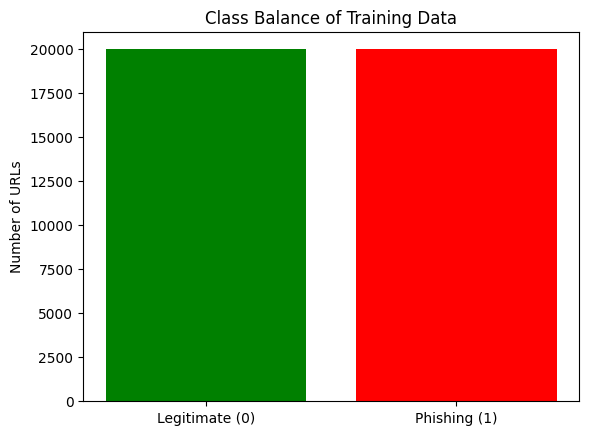

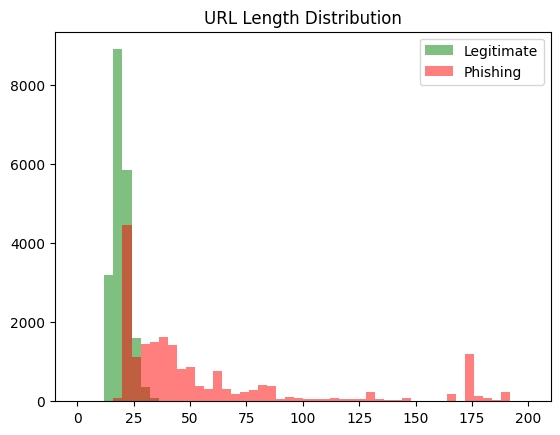

In [ ]:
# %pip install matplotlib
import matplotlib.pyplot as plt

# 1. Visualize the Class Balance
# I use 'final_df' because that's what I named it in the previous cell
count_classes = final_df['label'].value_counts()
plt.bar(['Legitimate (0)', 'Phishing (1)'], count_classes, color=['green', 'red'])
plt.title('Class Balance of Training Data')
plt.ylabel('Number of URLs')
plt.show()

# 2. Visualize URL Lengths
# Check lengths using 'final_df'
final_df['length'] = final_df['url'].apply(len)

plt.hist(final_df[final_df['label']==0]['length'], bins=50, alpha=0.5, label='Legitimate', color='green', range=(0, 200))
plt.hist(final_df[final_df['label']==1]['length'], bins=50, alpha=0.5, label='Phishing', color='red', range=(0, 200))
plt.title('URL Length Distribution')
plt.legend()
plt.show()